# L12 — Project 2: Pose Recognition (Solution)

<!-- TODO(public-repo): replace USER/REPO with the public course repo path before sharing -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yanluo/stem-on-stage-notebooks/blob/main/L12/02_pose_recognition/pose-recognition.ipynb)

**Goal:** train a model to tell two dance poses apart — **handstand** vs **arabesque** — from the micro:bit's orientation.

**The data is raw accelerometer.** The datalogger writes `t,x,y,z` (the same format as L11). The board has no tilt sensor, so this notebook **computes pitch and roll from x, y, z itself**, then learns the poses from those two angles.

**How this relates to L11.** Same machine-learning pipeline — `train_test_split` → `.fit` → `.score` → confusion matrix — with two differences:

- L11 classified *movement*, which is temporal, so it summarized 1-second windows into features. Pose is **static**: one reading describes orientation, so there is **no windowing** — each `(pitch, roll)` row is already a feature vector.
- We build the features (pitch, roll) out of the raw `x,y,z`, instead of using `mag`.

**Where to run:** Google Colab (no install). Each cell is `Shift + Enter`, top to bottom.

## Step 0 — Imports

In [1]:
import io
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("running in Colab" if IN_COLAB else "running locally")

running locally


## Step 1 — Where do pitch and roll come from?

The micro:bit has no dedicated tilt sensor. It infers tilt **from the accelerometer's reading of gravity**.

At rest, the only force on the accelerometer is gravity (~1000 mg, straight down). Flat with the logo up, that reads on the board's `z` axis. **Tilt the board and gravity spreads across multiple axes** — the relative sizes of `x, y, z` tell you the tilt. The standard formulas (an inverse-tangent that handles all four quadrants) are:

```
pitch = atan2(-x, sqrt(y**2 + z**2))   # forward/back tilt
roll  = atan2( y, z)                   # side-to-side tilt
```

On the device, `input.rotation(Rotation.PITCH/ROLL)` returns these directly. But the **datalogger only records raw `x,y,z`**, so when we analyze a capture we compute the angles ourselves. The loader below does exactly that.

**Caveat — the failure mode.** During fast motion the accelerometer reads gravity *plus* acceleration, so pitch/roll briefly lie. They are only reliable when the board is roughly still — which is fine for *pose*, since holding a posture means the dancer is at rest.

In [2]:
def load_microbit_log_csv(path_or_buf):
    """Read a datalogger CSV (t,x,y,z in mg) and add pitch, roll (degrees)."""
    df = pd.read_csv(path_or_buf)
    df = df.rename(columns={c: c.strip().lower() for c in df.columns})
    df["pitch"] = np.degrees(np.arctan2(-df["x"], np.sqrt(df["y"]**2 + df["z"]**2)))
    df["roll"]  = np.degrees(np.arctan2(df["y"], df["z"]))
    return df[["t", "x", "y", "z", "pitch", "roll"]]

## Step 2 — Upload your recordings

Capture **one recording per pose** with `wearable_pose.py` (or the L11 datalogger) — hold the handstand for a few seconds, save; do the same for the arabesque. Then run this cell and pick **all** the CSV files at once.

Each file is raw `t,x,y,z`. We don't know the pose yet — that's the next step.

Re-uploading a file with the **same name overwrites** the earlier copy, so if you record a better take you can just run this cell again — no `handstand (1).csv` clutter, and your labels below keep matching.

In [3]:
def clean_upload_name(name):
    # Colab appends ' (1)', ' (2)', ... when you upload a name that already
    # exists. Strip that suffix so re-uploading OVERWRITES the previous copy
    # instead of piling up handstand.csv, handstand (1).csv, handstand (2).csv.
    return re.sub(r" \(\d+\)(\.[^.]+)$", r"\1", name)


if IN_COLAB:
    from google.colab import files
    uploaded = files.upload()        # pick one or more CSVs
    raw_files = {}
    for name, content in uploaded.items():
        tidy = clean_upload_name(name)
        if name != tidy and os.path.exists(name):
            os.replace(name, tidy)   # overwrite the earlier copy on disk
        raw_files[tidy] = io.BytesIO(content)
else:
    # running locally: the two bundled sample recordings
    raw_files = {
        "sample-handstand.csv": "../../data/sample-handstand.csv",
        "sample-arabesque.csv": "../../data/sample-arabesque.csv",
    }

print("files ready to label:")
for name in raw_files:
    print("   ", name)

files ready to label:
    sample-handstand.csv
    sample-arabesque.csv


## Step 3 — Label each file with its pose

Tell the notebook which pose each file is. **Edit the dictionary** so every key matches an uploaded filename from the list above, and every value is the pose (`"handstand"` or `"arabesque"`).

We load each file, compute pitch/roll, attach the label, and stack them into one table.

In [4]:
LABELS = {
    "sample-handstand.csv": "handstand",
    "sample-arabesque.csv": "arabesque",
}

frames = []
for name, src in raw_files.items():
    d = load_microbit_log_csv(src)
    d["label"] = LABELS[name]
    frames.append(d)
    print(f"{name:24s} {len(d):4d} rows  ->  {LABELS[name]}")

df = pd.concat(frames, ignore_index=True)
df["label"].value_counts()

sample-handstand.csv       40 rows  ->  handstand
sample-arabesque.csv       40 rows  ->  arabesque


label
handstand    40
arabesque    40
Name: count, dtype: int64

## Step 4 — Look at your data first

Always plot before modeling. Each sample is a point on the pitch–roll plane; color it by pose. Two well-separated clouds means the poses are easy to tell apart; overlap means the model (and you) will struggle there.

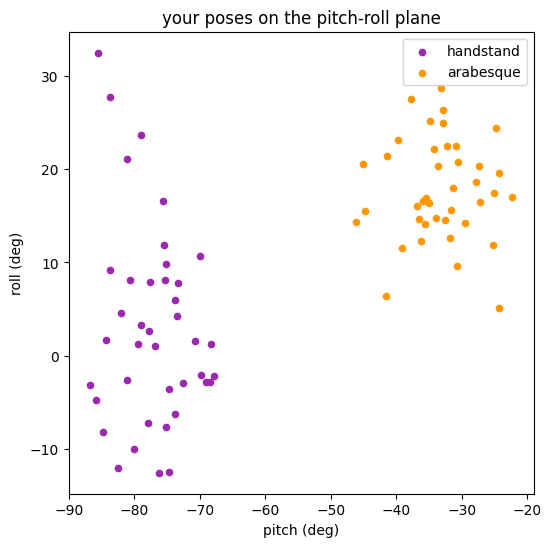

In [5]:
POSE_COLORS = {"handstand": "#9c27b0", "arabesque": "#ff9800"}

fig, ax = plt.subplots(figsize=(6, 6))
for name, color in POSE_COLORS.items():
    sub = df[df["label"] == name]
    ax.scatter(sub["pitch"], sub["roll"], s=20, color=color, label=name)
ax.set_xlabel("pitch (deg)")
ax.set_ylabel("roll (deg)")
ax.set_title("your poses on the pitch-roll plane")
ax.legend()
plt.show()

## Step 5 — Train/test split

We **never** test on data the model trained on — that measures memorization, not learning. Hold out 30%. The features are simply `pitch` and `roll` (no windowing — pose is static).

In [6]:
from sklearn.model_selection import train_test_split

FEATURES = ["pitch", "roll"]
X = df[FEATURES]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(len(X_train), "training examples")
print(len(X_test),  "test examples")

56 training examples
24 test examples


## Step 6 — Fit a decision tree

A **decision tree** is a flowchart of `if feature > threshold` questions. We keep it shallow (`max_depth=3`) so it stays small enough to read.

In [7]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

print(f"Train accuracy: {clf.score(X_train, y_train):.3f}")
print(f"Test  accuracy: {clf.score(X_test,  y_test):.3f}")

Train accuracy: 1.000
Test  accuracy: 1.000


## Step 7 — Read the rule it learned

This is the payoff. The tree learned its own pitch/roll thresholds to separate the poses — read them off and sanity-check against what you saw in the Step 4 plot.

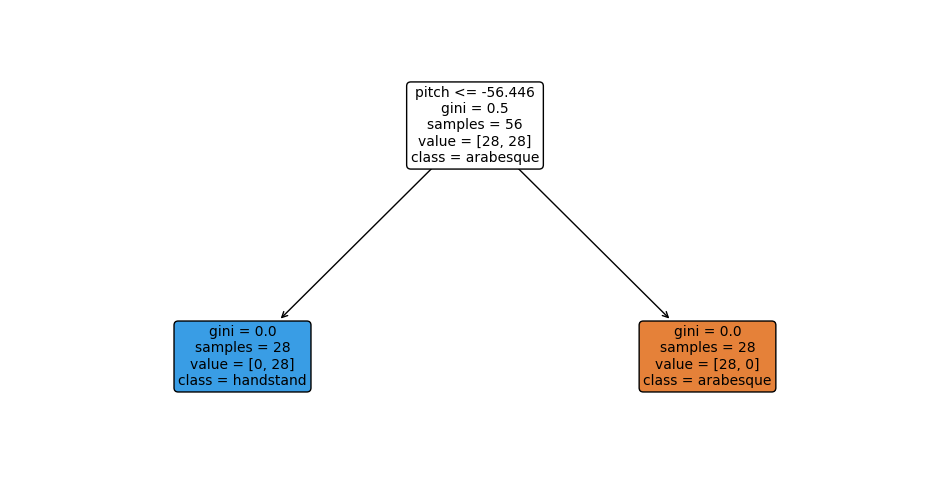

In [8]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(clf,
          feature_names=FEATURES,
          class_names=clf.classes_,
          filled=True, rounded=True, fontsize=10, ax=ax)
plt.show()

## Step 8 — Confusion matrix

A single accuracy number hides *which* pose gets mistaken for the other. Rows are the true pose, columns the predicted — the diagonal is correct, off-diagonal is mistakes.

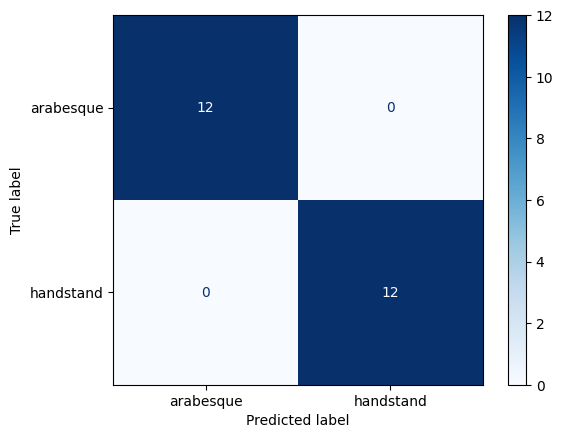

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap="Blues")
plt.show()

## Step 9 — See the regions the tree learned

Ask the trained tree to predict a pose for *every* point on the pitch–roll plane and shade the background by its answer. Your data points should sit inside the matching color — and you can see exactly where the boundary falls.

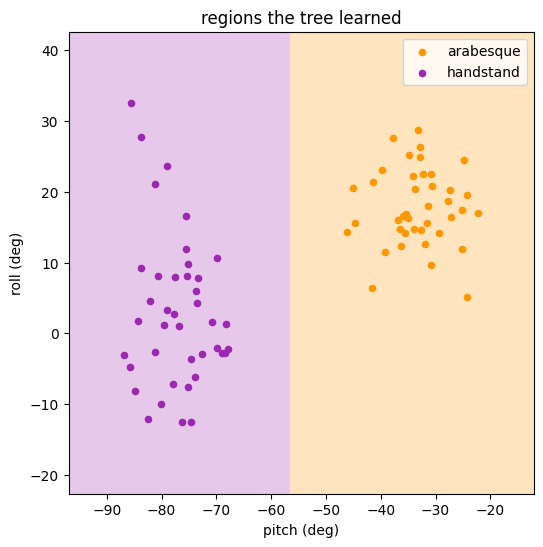

In [10]:
from matplotlib.colors import ListedColormap

classes = list(clf.classes_)
cmap = ListedColormap([POSE_COLORS[c] for c in classes])

p = np.linspace(df["pitch"].min() - 10, df["pitch"].max() + 10, 300)
r = np.linspace(df["roll"].min()  - 10, df["roll"].max()  + 10, 300)
pp, rr = np.meshgrid(p, r)
grid = pd.DataFrame({"pitch": pp.ravel(), "roll": rr.ravel()})

pred = clf.predict(grid)
code_grid = np.array([classes.index(c) for c in pred]).reshape(pp.shape)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pcolormesh(pp, rr, code_grid, cmap=cmap, alpha=0.25, shading="auto")
for name in classes:
    sub = df[df["label"] == name]
    ax.scatter(sub["pitch"], sub["roll"], s=20, color=POSE_COLORS[name], label=name)
ax.set_xlabel("pitch (deg)")
ax.set_ylabel("roll (deg)")
ax.set_title("regions the tree learned")
ax.legend()
plt.show()

## Step 10 — Predict a new pose

Once trained, the model takes a fresh `(pitch, roll)` and returns a pose — the same call you'd make on data streamed from the device.

In [11]:
def predict_pose(pitch, roll):
    x = pd.DataFrame([[pitch, roll]], columns=FEATURES)
    answer = clf.predict(x)[0]
    print(f"pitch={pitch:>5}°, roll={roll:>5}°  ->  {answer}")
    return answer

predict_pose(-78,  0)    # expect handstand
predict_pose(-35, 20);   # expect arabesque

pitch=  -78°, roll=    0°  ->  handstand
pitch=  -35°, roll=   20°  ->  arabesque


## What to build next (L13 starting goals)

1. **Add a third pose** — record it, label it, re-run. The tree picks up the new region automatically; no new code.
2. **Drive a NeoPixel color** from the predicted pose (e.g. handstand = blue, arabesque = orange).
3. **Smooth the prediction** with a 1-second majority vote so a brief wobble doesn't flip the output.
4. **Per-dancer calibration** — record each dancer's natural standing pose and subtract that offset before classifying.

## Reflect (homework)

Write 3–4 sentences in this cell:

- Looking at the Step 4 plot, which feature (pitch or roll) separates handstand from arabesque better? Does the Step 7 tree agree?
- What test accuracy did you get, and did the confusion matrix show any mistakes?
- Pose needed no windowing, but L11 movement did. In your own words, why?

*Your answer here.*